<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/09_Pytorch_model_deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

torch version: 2.6.0+cu124
torchvision version: 0.21.0+cu124


In [1]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 19.99 MiB/s, done.
Resolving deltas: 100% (2656/2656), done.
Updating files: 100% (248/248), done.


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] Did not find data/pizza_steak_sushi_20_percent directory, creating one...
[INFO] Downloading pizza_steak_sushi_20_percent.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip...
[INFO] Unzipping pizza_steak_sushi_20_percent.zip data...


PosixPath('data/pizza_steak_sushi_20_percent')

In [4]:
train_dir = data_20_percent_path/"train"
test_dir =data_20_percent_path/"test"

In [5]:
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2_transforms = effnetb2_weights.transforms()

effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

for param in effnetb2.parameters():
    param.requires_grad = False


Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 168MB/s]


In [6]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [7]:
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408, out_features=3, bias=True)
)

In [8]:
def create_effnetb2_model(num_classes:int=3,
                          seed:int=42):

  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  transforms = weights.transforms()
  model=torchvision.models.efficientnet_b2(weights=weights)

  for params in model.parameters():
    params.requires_grad =False

  torch.manual_seed(seed)
  model.classifier = nn.Sequential(
      nn.Dropout(p=0.3,inplace=True),
      nn.Linear(in_features=1408, out_features=num_classes)
  )

  return model, transforms

In [9]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)

In [10]:
from torchinfo import summary

# # Print EffNetB2 model summary (uncomment for full output)
summary(effnetb2,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [11]:
from going_modular.going_modular import data_setup
train_dataloader_effnetb2,test_dataloader_effnetb2,class_names = data_setup.create_dataloaders(train_dir=train_dir,test_dir=test_dir,transform=effnetb2_transforms,batch_size=32)


In [13]:
optimizer = torch.optim.Adam(params=effnetb2.parameters(),lr=1e-3)

loss_fn = torch.nn.CrossEntropyLoss()

from going_modular.going_modular import engine

set_seeds(42)
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader = test_dataloader_effnetb2,
                                optimizer =optimizer,
                                loss_fn=loss_fn,
                                epochs=10,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9839 | train_acc: 0.5667 | test_loss: 0.7393 | test_acc: 0.9409
Epoch: 2 | train_loss: 0.7135 | train_acc: 0.8396 | test_loss: 0.5862 | test_acc: 0.9409
Epoch: 3 | train_loss: 0.5874 | train_acc: 0.8958 | test_loss: 0.4891 | test_acc: 0.9563
Epoch: 4 | train_loss: 0.4488 | train_acc: 0.9146 | test_loss: 0.4338 | test_acc: 0.9409
Epoch: 5 | train_loss: 0.4277 | train_acc: 0.9125 | test_loss: 0.3907 | test_acc: 0.9443
Epoch: 6 | train_loss: 0.4392 | train_acc: 0.8896 | test_loss: 0.3525 | test_acc: 0.9688
Epoch: 7 | train_loss: 0.4246 | train_acc: 0.8771 | test_loss: 0.3263 | test_acc: 0.9563
Epoch: 8 | train_loss: 0.3885 | train_acc: 0.8979 | test_loss: 0.3465 | test_acc: 0.9443
Epoch: 9 | train_loss: 0.3795 | train_acc: 0.8812 | test_loss: 0.3127 | test_acc: 0.9193
Epoch: 10 | train_loss: 0.3752 | train_acc: 0.8688 | test_loss: 0.2811 | test_acc: 0.9625


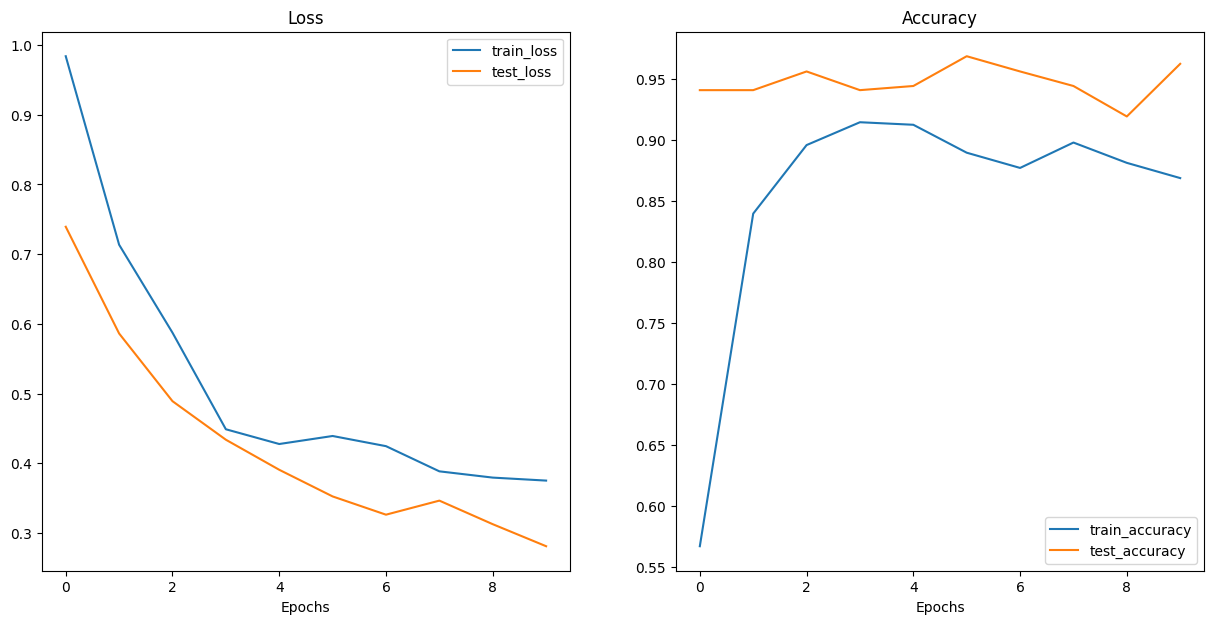

In [14]:
from helper_functions import plot_loss_curves

plot_loss_curves(effnetb2_results)

In [15]:
from going_modular.going_modular import utils

utils.save_model(model=effnetb2,
                 target_dir = "models",
                 model_name = "09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth")


[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth


In [16]:
from pathlib import Path
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth").stat().st_size/1024/1024

print(f"Pretrained EffNetB2 model size: {pretrained_effnetb2_model_size:.2f} MB")

Pretrained EffNetB2 model size: 29.86 MB


In [17]:
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

In [91]:
effnetb2_stats = {"test_loss":effnetb2_results["test_loss"][-1],
                  "test_acc":effnetb2_results["test_acc"][-1],
                  "number_of_parameters":effnetb2_total_params,
                  "model_size(MB)":pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.2810868382453918,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.8638858795166}

In [20]:
vit = torchvision.models.vit_b_16()
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [24]:
def create_vit_model(num_classes:int=3,
                     seed:int=42):
  weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  transforms = weights.transforms()
  model = torchvision.models.vit_b_16(weights=weights)

  for params in model.parameters():
    params.requires_grad=False

  torch.manual_seed(seed)
  model.heads = nn.Sequential(

      nn.Linear(in_features=768, out_features=num_classes)
  )

  return model,transforms


In [25]:
vit ,vit_transforms = create_vit_model(num_classes=3,
                                       seed=42)

In [26]:
from torchinfo import summary

# # Print ViT feature extractor model summary (uncomment for full output)
summary(vit,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [27]:
from going_modular.going_modular import data_setup
train_dataloader_vit,test_dataloader_vit,class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                     test_dir=test_dir,
                                                                                     transform=vit_transforms,
                                                                                     batch_size=32)

In [28]:
optimizer = torch.optim.Adam(params=vit.parameters(),lr=1e-3)

loss_fn = torch.nn.CrossEntropyLoss()

set_seeds(42)
from going_modular.going_modular import engine
vit_model_results = engine.train(model=vit,
                                 train_dataloader=train_dataloader_vit,
                                 test_dataloader=test_dataloader_vit,
                                 optimizer=optimizer,
                                 loss_fn = loss_fn,
                                 epochs=10,
                                 device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7020 | train_acc: 0.7521 | test_loss: 0.2714 | test_acc: 0.9381
Epoch: 2 | train_loss: 0.2532 | train_acc: 0.9062 | test_loss: 0.1672 | test_acc: 0.9602
Epoch: 3 | train_loss: 0.1764 | train_acc: 0.9542 | test_loss: 0.1273 | test_acc: 0.9693
Epoch: 4 | train_loss: 0.1276 | train_acc: 0.9625 | test_loss: 0.1074 | test_acc: 0.9722
Epoch: 5 | train_loss: 0.1159 | train_acc: 0.9646 | test_loss: 0.0953 | test_acc: 0.9784
Epoch: 6 | train_loss: 0.1274 | train_acc: 0.9375 | test_loss: 0.0832 | test_acc: 0.9722
Epoch: 7 | train_loss: 0.0897 | train_acc: 0.9771 | test_loss: 0.0845 | test_acc: 0.9784
Epoch: 8 | train_loss: 0.0919 | train_acc: 0.9812 | test_loss: 0.0764 | test_acc: 0.9722
Epoch: 9 | train_loss: 0.0922 | train_acc: 0.9792 | test_loss: 0.0734 | test_acc: 0.9784
Epoch: 10 | train_loss: 0.0658 | train_acc: 0.9833 | test_loss: 0.0644 | test_acc: 0.9847


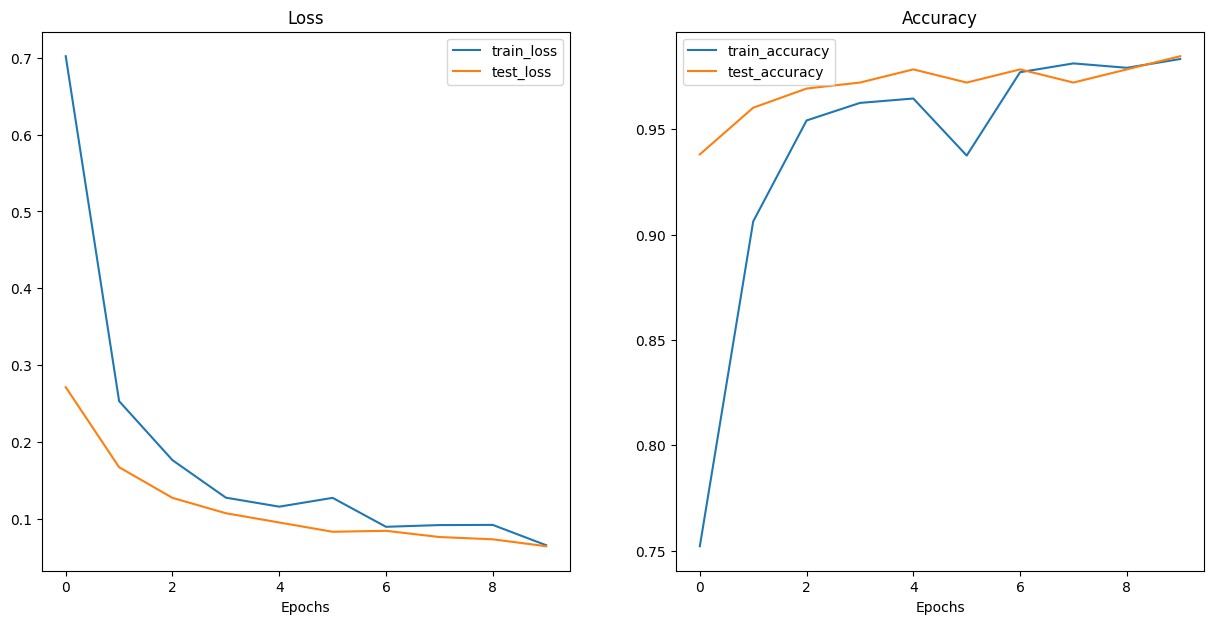

In [29]:
from helper_functions import plot_loss_curves

plot_loss_curves(vit_model_results)

In [30]:
from going_modular.going_modular import utils
utils.save_model(model= vit,
                 target_dir="models",
                 model_name = "09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


In [57]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


In [58]:
# Count number of parameters in ViT
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85800963

In [75]:
vit_model_stats = {"test_loss":vit_model_results["test_loss"][-1],
                   "test_acc":vit_model_results["test_acc"][-1],
                   "number_of_parameters":vit_total_params,
                   "model_size(MB)":pretrained_vit_model_size}
vit_model_stats

{'test_loss': 0.06443451717495918,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size(MB)': 327}

In [76]:
from pathlib import Path
print(f"[INFO] finding all filepaths ending with .jpg in directory:{test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] finding all filepaths ending with .jpg in directory:data/pizza_steak_sushi_20_percent/test


[PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1994748.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/3177743.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2903125.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2819945.jpg')]

In [77]:
import pathlib
import torch
from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import List,Dict
def pred_and_store(paths:List[pathlib.Path],
                   model:torch.nn.Module,
                   transform:torchvision.transforms,
                   class_names:List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu")->List[Dict]:

    pred_list = []

    for path in tqdm(paths):
      pred_dict = {}

      pred_dict["image_path"]=path
      class_name = path.parent.stem
      pred_dict["class_name"]=class_name

      start_time = timer()

      img = Image.open(path)

      transformed_img = transform(img).unsqueeze(dim=0).to(device)
      model.to(device)

      model.eval()

      with torch.inference_mode():
        print(f"[INFO] making prediction on {path}...")
        pred_logit = model(transformed_img)
        pred_prob =torch.softmax(pred_logit,dim=1)
        pred_label = torch.argmax(pred_prob,dim=1)
        pred_class= class_names[pred_label.cpu()]


        pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(),4)
        pred_dict["pred_class"] = pred_class
        end_time =timer()
        pred_dict["time_for_pred"]=round(end_time-start_time,4)

      pred_dict["correct"]=class_name==pred_class

      pred_list.append(pred_dict)

    return pred_list




In [78]:
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu")

  0%|          | 0/150 [00:00<?, ?it/s]

[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/1994748.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/3177743.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2903125.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2819945.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/46797.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/1203702.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/3834718.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/715227.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/511818.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/780283.jpg...
[INFO] making prediction on data/pizz

In [79]:
# Inspect the first 2 prediction dictionaries
effnetb2_test_pred_dicts[:2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.7403,
  'pred_class': 'sushi',
  'time_for_pred': 0.0984,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1994748.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.5418,
  'pred_class': 'sushi',
  'time_for_pred': 0.0934,
  'correct': True}]

In [80]:
# Turn the test_pred_dicts into a DataFrame
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.7403,sushi,0.0984,True
1,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.5418,sushi,0.0934,True
2,data/pizza_steak_sushi_20_percent/test/sushi/3...,sushi,0.8318,sushi,0.0943,True
3,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.8018,sushi,0.0975,True
4,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.8833,sushi,0.0899,True


In [81]:
# Check number of correct predictions
effnetb2_test_pred_df.correct.value_counts()

,count
correct,
True,144
False,6


In [82]:
# Find the average time per prediction
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.098 seconds


In [93]:
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.2810868382453918,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size(MB)': 29.8638858795166,
 'time_per_pred_cpu': np.float64(0.098)}

In [84]:
from os import path
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device="cpu")


  0%|          | 0/150 [00:00<?, ?it/s]

[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/1994748.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/3177743.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2903125.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/2819945.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/46797.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/1203702.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/3834718.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/715227.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/511818.jpg...
[INFO] making prediction on data/pizza_steak_sushi_20_percent/test/sushi/780283.jpg...
[INFO] making prediction on data/pizz

In [85]:
vit_test_pred_dicts[:2]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/2903621.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.9072,
  'pred_class': 'sushi',
  'time_for_pred': 0.4552,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/sushi/1994748.jpg'),
  'class_name': 'sushi',
  'pred_prob': 0.9655,
  'pred_class': 'sushi',
  'time_for_pred': 0.4544,
  'correct': True}]

In [86]:
import pandas as pd
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9072,sushi,0.4552,True
1,data/pizza_steak_sushi_20_percent/test/sushi/1...,sushi,0.9655,sushi,0.4544,True
2,data/pizza_steak_sushi_20_percent/test/sushi/3...,sushi,0.9629,sushi,0.4207,True
3,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9975,sushi,0.4508,True
4,data/pizza_steak_sushi_20_percent/test/sushi/2...,sushi,0.9795,sushi,0.5299,True


In [87]:
vit_test_pred_df.correct.value_counts()

,count
correct,
True,148
False,2


In [88]:
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(),4)
print(f"VIT average time for prediction: {vit_average_time_per_pred}")

VIT average time for prediction: 0.4459


In [89]:
vit_model_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_model_stats

{'test_loss': 0.06443451717495918,
 'test_acc': 0.984659090909091,
 'number_of_parameters': 85800963,
 'model_size(MB)': 327,
 'time_per_pred_cpu': np.float64(0.4459)}

In [94]:
df = pd.DataFrame([effnetb2_stats,vit_model_stats])

df["model"] = ["EffnetB2","ViT"]

df["test_acc"]=round(df["test_acc"]*100,2)
df

,test_loss,test_acc,number_of_parameters,model_size(MB),time_per_pred_cpu,model
0,0.281087,96.25,7705221,29.863886,0.0980,EffnetB2
1,0.064435,98.47,85800963,327.000000,0.4459,ViT


In [95]:
pd.DataFrame(data=(df.set_index("model").loc["ViT"]/df.set_index("model").loc["EffnetB2"]),
             columns=["ViT to EffnetB2 ratios"]).T

,test_loss,test_acc,number_of_parameters,model_size(MB),time_per_pred_cpu
ViT to EffnetB2 ratios,0.229233,1.023065,11.135432,10.94968,4.55


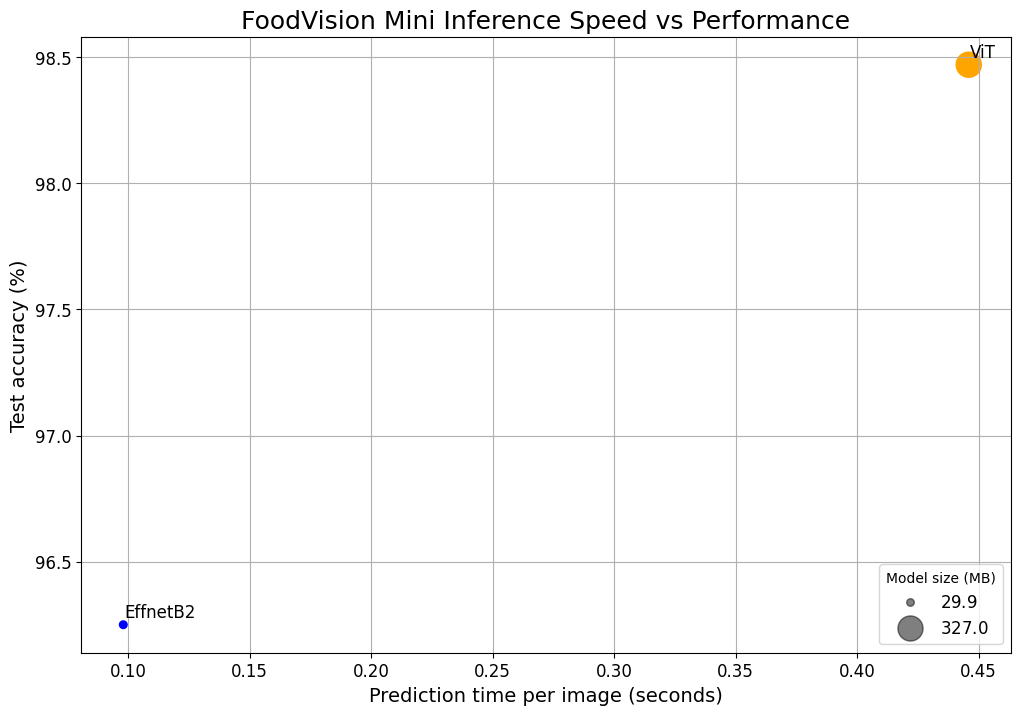

In [99]:
# 1. Create a plot from model comparison DataFrame
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(data=df,
                     x="time_per_pred_cpu",
                     y="test_acc",
                     c=["blue", "orange"], # what colours to use?
                     s="model_size(MB)") # size the dots by the model sizes

# 2. Add titles, labels and customize fontsize for aesthetics
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

# 3. Annotate with model names
for index, row in df.iterrows():
    ax.annotate(text=row["model"], # note: depending on your version of Matplotlib, you may need to use "s=..." or "text=...", see: https://github.com/faustomorales/keras-ocr/issues/183#issuecomment-977733270
                xy=(row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03),
                size=12)

# 4. Create a legend based on model sizes
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles,
                              labels,
                              loc="lower right",
                              title="Model size (MB)",
                              fontsize=12)

# Save the figure
!mkdir images/
plt.savefig("images/09-foodvision-mini-inference-speed-vs-performance.jpg")

# Show the figure
plt.show()

###DEPLOYING THE EFFNET MODEL

In [101]:
# Import/install Gradio
try:
    import gradio as gr
except:
    !pip -q install gradio
    import gradio as gr

print(f"Gradio version: {gr.__version__}")

Gradio version: 5.37.0


In [102]:
effnetb2.to("cpu")

next(iter(effnetb2.parameters())).device

device(type='cpu')

In [107]:
from typing import Dict ,Tuple

def predict(img)->Tuple[Dict,List]:
    start_time=timer()
    img = effnetb2_transforms(img).unsqueeze(0)

    effnetb2.eval()
    with torch.inference_mode():

      pred_probs = torch.softmax(effnetb2(img),dim=1)

    pred_labels_and_probs = {class_names[i]:float(pred_probs[0][i]) for i in range(len(class_names))}

    end_time =timer()

    pred_time = round(end_time-start_time,5)

    return pred_labels_and_probs,pred_time


In [108]:
import random
from PIL import Image
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

random_image_path = random.sample(test_data_paths,k=1)[0]

image= Image.open(random_image_path)
print(f"[INFO] predicting on image at path :{random_image_path}")

pred_dict,pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] predicting on image at path :data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg
Prediction label and probability dictionary: 
{'pizza': 0.9584818482398987, 'steak': 0.017330367118120193, 'sushi': 0.024187760427594185}
Prediction time: 0.09338 seconds


In [109]:
# Create a list of example inputs to our Gradio demo
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/steak/3479599.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/sushi/2352914.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/697562.jpg']]

In [110]:
import gradio as gr
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

demo = gr.Interface(fn=predict,
                    inputs=gr.Image(type='pil'),
                    outputs = [gr.Label(num_top_classes=3,label="Predictions"),
                               gr.Number(label="Prediction time (s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)
demo.launch(debug=False,
            share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7ffeaeb79526a26fa2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [111]:
import shutil
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove files that might already exist there and create new directory
if foodvision_mini_demo_path.exists():
    shutil.rmtree(foodvision_mini_demo_path)
# If the file doesn't exist, create it anyway
foodvision_mini_demo_path.mkdir(parents=True,
                                exist_ok=True)

# Check what's in the folder
!ls demos/foodvision_mini/

In [112]:
import shutil
from pathlib import Path

# 1. Create an examples directory
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True, exist_ok=True)

# 2. Collect three random test dataset image paths
foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]

# 3. Copy the three random images to the examples directory
for example in foodvision_mini_examples:
    destination = foodvision_mini_examples_path / example.name
    print(f"[INFO] Copying {example} to {destination}")
    shutil.copy2(src=example, dst=destination)

[INFO] Copying data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg to demos/foodvision_mini/examples/592799.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg to demos/foodvision_mini/examples/3622237.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg to demos/foodvision_mini/examples/2582289.jpg


In [113]:
import os

# Get example filepaths in a list of lists
example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/592799.jpg'], ['examples/3622237.jpg'], ['examples/2582289.jpg']]

In [116]:
import shutil

# Create a source path for our target model
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth"

# Create a destination path for our target model
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[1]

# Try to move the file
try:
    print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")

    # Move the model
    shutil.move(src=effnetb2_foodvision_mini_model_path,
                dst=effnetb2_foodvision_mini_model_destination)

    print(f"[INFO] Model move complete.")

# If the model has already been moved, check if it exists
except:
    print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth to demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth
[INFO] Model move complete.


In [120]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3,
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head.
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model.
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )

    return model, transforms

Overwriting demos/foodvision_mini/model.py


In [122]:
%%writefile demos/foodvision_mini/app.py
### 1. Imports and class names setup ###
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ["pizza", "steak", "sushi"]

### 2. Model and transforms preparation ###

# Create EffNetB2 model
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=3, # len(class_names) would also work
)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

### 3. Predict function ###

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()

    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)

    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)

    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)

    # Return the prediction dictionary and prediction time
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

# Launch the demo!
demo.launch()

Writing demos/foodvision_mini/app.py


In [123]:
%%writefile demos/foodvision_mini/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_mini/requirements.txt


In [124]:
!ls demos/foodvision_mini

09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth
app.py
examples
model.py
requirements.txt


In [125]:
# Change into and then zip the foodvision_mini folder but exclude certain files
!cd demos/foodvision_mini && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"

# Download the zipped FoodVision Mini app (if running in Google Colab)
try:
    from google.colab import files
    files.download("demos/foodvision_mini.zip")
except:
    print("Not running in Google Colab, can't use google.colab.files.download(), please manually download.")

  adding: 09_pretrained_effnetb2_feature_extractor_pizaa_stesk_sushi_20_percent.pth (deflated 8%)
  adding: app.py (deflated 57%)
  adding: examples/ (stored 0%)
  adding: examples/592799.jpg (deflated 1%)
  adding: examples/3622237.jpg (deflated 0%)
  adding: examples/2582289.jpg (deflated 17%)
  adding: model.py (deflated 56%)
  adding: requirements.txt (deflated 4%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>